Title: "Cancer Classification using Deep Learning"

Goal: Predict whether a breast tumor is malignant or benign using a neural network.

Dataset: Breast Cancer Wisconsin dataset (scikit-learn)

In [41]:
!pip install tensorflow
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [42]:
##Load dataset
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
data.DESCR

X=data.data             ##stores all the input features
y=data.target           ##stores the answer we want the model to learn

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (569, 30)
y shape: (569,)


In [43]:
#Split the dataset into train and test set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [44]:
##Feature scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [45]:
X_train.shape

(455, 30)

In [46]:
X_test.shape

(114, 30)

In [47]:
#build neural network
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.layers import ReLU, ELU, PReLU, LeakyReLU
from tensorflow.keras.layers import Dropout

In [48]:
#Initialise the neural network
classifier=Sequential()

#Add input layer
classifier.add(Input(shape=(30,)))
classifier.add(Dense(units=30, activation = 'relu'))

##Add first hidden layer
classifier.add(Dense(units=64, activation= 'relu'))

##Add second hidden layer
classifier.add(Dense(units=32, activation = 'relu'))

##Add third hidden layer
classifier.add(Dense(units=16, activation = 'relu'))

##Add output layer
classifier.add(Dense(units=1, activation = 'sigmoid'))

In [49]:
##Compile the model
classifier.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [50]:
##Early Stopping
import tensorflow as tf
early_stopping=tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.0001,
    patience=10,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=True,
    start_from_epoch=0,
)

In [51]:
##Train model
model_history=classifier.fit(X_train, y_train, validation_data=(X_test, y_test), validation_split=0.2, batch_size=16, epochs=100, callbacks=early_stopping)


Epoch 1/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 115ms/step - accuracy: 0.6857 - loss: 0.5600 - val_accuracy: 0.9649 - val_loss: 0.3724
Epoch 2/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9582 - loss: 0.2167 - val_accuracy: 0.9649 - val_loss: 0.1126
Epoch 3/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9714 - loss: 0.0940 - val_accuracy: 0.9737 - val_loss: 0.0795
Epoch 4/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9802 - loss: 0.0675 - val_accuracy: 0.9737 - val_loss: 0.0777
Epoch 5/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9868 - loss: 0.0570 - val_accuracy: 0.9649 - val_loss: 0.0845
Epoch 6/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9890 - loss: 0.0442 - val_accuracy: 0.9649 - val_loss: 0.0768
Epoch 7/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9912 - loss: 0.0396 - val_accuracy: 0.9649 - val_loss: 0.0797
Epoch 8/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9934 - loss: 0.0334 - val_accuracy: 0

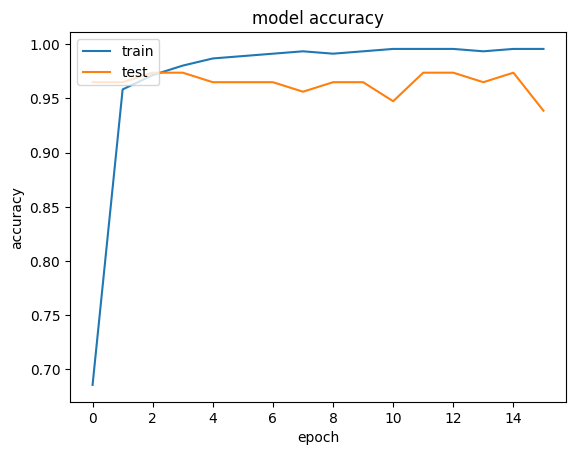

In [52]:
##Summarize the history for accuracy
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'],loc='upper left')
plt.show()

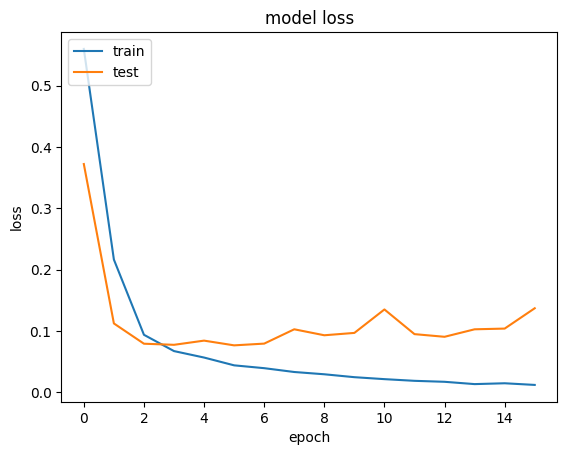

In [53]:
##Summarize the history for loss
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'],loc='upper left')
plt.show()

In [54]:
##Predictions
y_pred=(classifier.predict(X_test))
y_pred=(y_pred>0.5)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


In [58]:
##Confusion matrix
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
cm

array([[41,  2],
       [ 2, 69]])

In [56]:
##Calculate the accuracy
from sklearn.metrics import accuracy_score
score=accuracy_score(y_pred,y_test)
score

0.9649122807017544

In [59]:
##Classification report
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95        43
           1       0.97      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114

